# Chatbot with HITL (Human in the Loop)

Agent 처리도중 사람의 개입이 필요한 경우 iterrupt처리할 수 있다.
- 사람의 개입(tool)
- 사람 메세지(command)로 대화를 재개할 수 있다.

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['PINECONE_API_KEY'] = os.getenv('PINECONE_API_KEY')
os.environ['COHERE_API_KEY'] = os.getenv('COHERE_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [ ]:
# Tavily 도구 생성
from langchain_tavily import TavilySearch

tavilly_tool = TavilySearch(max_results=3)

### 사람 개입 도구

In [ ]:
from langchain_core.tools import tool   # Tool 데코레이터
from langgraph.types import interrupt   # 사람 응답을 기다리는 interrupt

@tool
def human_assist(query):
    """사람의 개입이 필요하면 이 도구를 사용합니다."""
    human_response = interrupt({'query': query})    # 사람의 응답이 올때까지 입력 대기
    return human_response['data']       # 사람의 응답 데이터

In [ ]:
answer = human_assist.invoke({'query': '질문?'})   # @tool 데코레이터가 붙은 도구는 .invoke()로 호출
print(answer)

In [ ]:
from typing import TypedDict, Annotated, List     # 타입 힌트 도구
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    messages: Annotated[List, add_messages]  # messages 필드가 add_messages 규칙으로 누적 저장

llm = init_chat_model('gpt-5.6-luna')
tools = [tavilly_tool, human_assist]         # 웹 검색 + 사람 개입 도구
llm_with_tools = llm.bind_tools(tools)

# State의 messages를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):
    response = llm_with_tools.invoke(state['messages'])  # tools가 바인딩된 llm으로 호출
    return {'messages': [response]}  # add_messages 규칙에 의해 기존 messages에 응답이 누적됨

In [7]:
# 메모리 기반 체크포인트 저장소 (인메모리)
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()  # 상태 체크포인트를 RAM에 저장하는 객체

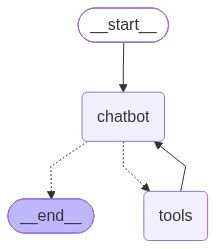

In [8]:
# langgraph.prebuilt 모듈의 ToolNode, tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(State)     # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)


builder.add_edge(START, 'chatbot')  # 시작 노드 -> chatbot 노드

builder.add_node('chatbot', chatbot)  # chatbot 노드
builder.add_node('tools', tool_node)  # tools 노드

builder.add_conditional_edges('chatbot', tools_condition)
builder.add_edge('tools', 'chatbot')

graph = builder.compile(checkpointer = memory) # 체크포인터를 포함하여 

graph  # 그래프 객체

### 챗봇 실행

In [ ]:
from pprint import pprint

# 스냅샷 출력 함수 : 저장된 상태(messages)와 다음 실행 노드(next) 확인
def print_snapshot(graph, config):
    snapshot = graph.get_state(config)      # 해당 configu(thread_id)의 스냅샷 조회

    if 'messages' in snapshot.values:       # messages가 존재하면
        print(snapshot.values['messages'])  # 누적된 messages 출력
    else:
        print('메세지가 없음!')

    print(f"Next: {snapshot.next}")         # 다음 실행 노드 출력

print(print_snapshot(graph, {"configurable": {'thread_id': 'user1'}}))

메세지가 없음!
Next: ()
None


In [10]:
user1_config = {'configurable': {'thread_id': 'user1'}}

state = {'messages': [('human', 'langgraph를 멀티에이전트 설계에서 사용하는 이유는 뭐야?')]}    # HumanMessage 객체 내 메세지 구현 

response = graph.invoke(state, user1_config)      # 그래프 실행 (START -> CHATBOT -> (tool 루프)or END)

print(response['messages'][-1].content)

LangGraph를 멀티에이전트 설계에 사용하는 가장 큰 이유는 **여러 에이전트의 협업 흐름을 그래프 형태로 명확하게 정의하고 제어하기 쉽기 때문**입니다.

주요 이유는 다음과 같습니다.

1. **에이전트 간 작업 흐름을 명시적으로 표현**
   - 각 에이전트를 노드(node)로 정의하고
   - 에이전트 간 호출, 분기, 반복, 종료 조건을 엣지(edge)로 표현합니다.
   - 예: `계획 수립 → 자료 조사 → 코드 작성 → 검증 → 수정`

2. **복잡한 조건부 흐름과 반복 처리 지원**
   - 단순한 일렬 체인뿐 아니라 다음과 같은 흐름을 만들 수 있습니다.
   - 특정 결과에 따른 에이전트 선택
   - 검증 실패 시 이전 단계로 되돌아가기
   - 여러 에이전트가 작업한 뒤 결과 통합
   - 종료 조건까지 반복 실행

3. **공유 상태(state) 관리**
   - 여러 에이전트가 공통 상태를 읽고 수정할 수 있습니다.
   - 예를 들어 다음 정보를 상태로 유지할 수 있습니다.
     - 사용자 요청
     - 중간 결과
     - 대화 기록
     - 작업 진행 상황
     - 검증 결과
   - 에이전트마다 별도의 메모리를 조합하는 것도 가능합니다.

4. **병렬 실행과 결과 통합**
   - 여러 조사 에이전트를 동시에 실행한 뒤, 하나의 종합 에이전트가 결과를 합칠 수 있습니다.
   - 예:
     ```text
     웹 검색 에이전트 ─┐
     문서 분석 에이전트 ─┼→ 종합 에이전트
     데이터 분석 에이전트 ─┘
     ```

5. **체크포인트와 중단 후 재개**
   - 실행 상태를 저장할 수 있어 긴 작업이나 실패 가능성이 있는 작업을 이어서 실행할 수 있습니다.
   - 사용자의 승인이 필요한 지점에서 멈췄다가 다시 진행하는 것도 가능합니다.

6. **Human-in-the-loop 구현**
   - 중요한 작업 전에 사람의 승인을 받도록 만들 수 있습니다.
   - 예:
    

In [11]:
print_snapshot(graph, user1_config)

[HumanMessage(content='langgraph를 멀티에이전트 설계에서 사용하는 이유는 뭐야?', additional_kwargs={}, response_metadata={}, id='6985984c-975c-473a-ae53-bbe80f5c84ea'), AIMessage(content='LangGraph를 멀티에이전트 설계에 사용하는 가장 큰 이유는 **여러 에이전트의 협업 흐름을 그래프 형태로 명확하게 정의하고 제어하기 쉽기 때문**입니다.\n\n주요 이유는 다음과 같습니다.\n\n1. **에이전트 간 작업 흐름을 명시적으로 표현**\n   - 각 에이전트를 노드(node)로 정의하고\n   - 에이전트 간 호출, 분기, 반복, 종료 조건을 엣지(edge)로 표현합니다.\n   - 예: `계획 수립 → 자료 조사 → 코드 작성 → 검증 → 수정`\n\n2. **복잡한 조건부 흐름과 반복 처리 지원**\n   - 단순한 일렬 체인뿐 아니라 다음과 같은 흐름을 만들 수 있습니다.\n   - 특정 결과에 따른 에이전트 선택\n   - 검증 실패 시 이전 단계로 되돌아가기\n   - 여러 에이전트가 작업한 뒤 결과 통합\n   - 종료 조건까지 반복 실행\n\n3. **공유 상태(state) 관리**\n   - 여러 에이전트가 공통 상태를 읽고 수정할 수 있습니다.\n   - 예를 들어 다음 정보를 상태로 유지할 수 있습니다.\n     - 사용자 요청\n     - 중간 결과\n     - 대화 기록\n     - 작업 진행 상황\n     - 검증 결과\n   - 에이전트마다 별도의 메모리를 조합하는 것도 가능합니다.\n\n4. **병렬 실행과 결과 통합**\n   - 여러 조사 에이전트를 동시에 실행한 뒤, 하나의 종합 에이전트가 결과를 합칠 수 있습니다.\n   - 예:\n     ```text\n     웹 검색 에이전트 ─┐\n     문서 분석 에이전트 ─┼→ 종합 에이전트\n     데이터 분석 에이전트 ─┘\n     ```\n\n5. 

### 케이크샾 에이전트

In [17]:
system_prompt = """
**Instruction**
사용자는 케이크 주문, 메뉴 문의, 매장 정보 등을 챗봇에 요청할 수 있다.
챗봇은 친절하고 정확하게 답변한다.

**Context**
당신은 프리미엄 케이크샵의 공식 챗봇이다.
- 운영 시간: 매일 09:00–21:00
- 주요 메뉴: 생크림 케이크, 초코 케이크, 치즈 케이크, 시즌 한정 케이크
- 매장 위치: 서울 강남구 신사동 123-45
- 연락처: 02-1234-5678

**Example**
> **User:** "다음 주 수요일 오후 3시에 케이크 예약 가능한가요?"
> **Bot:** "안녕하세요! 다음 주 수요일(2025년 7월 16일) 오후 3시에 예약 가능합니다. 예약을 원하시면 성함과 연락처를 알려주세요."

**Output Indicator**
- 챗봇 응답은 한 문단 이내로 간결하게 제시한다.
- 필요한 경우 날짜·시간은 YYYY년 M월 D일 형식으로 명시한다.
- 추가 질문이 필요할 때에는 "추가로 궁금하신 점이 있으면 말씀해주세요." 로 마무리한다.
- 그외 답변하기 어려운 경우, human_assist 도구를 사용하여 인간의 도움을 요청한다.
"""  # 시스템 지침/컨텍스트/출력 규칙 정의

user_prompt = '당근케익 4호가 홈페이지에서 구매가 안되는데, 매니져님께 구매가능여부를 묻고 싶어요.'  # 사용자 요청 문장

# 치환할 변수가 없으므로 템플릿 없이 메시지 리스트를 직접 구성
state = {'messages': [
    ('system', system_prompt),
    ('human', user_prompt),
]}
response = graph.invoke(state, user_prompt)
print(response['messages'][-1].content)

AttributeError: 'str' object has no attribute 'items'

In [19]:
# 사람 개입
from langgraph.types import Command

human_response = "물론입니다. 구매 가능하시고요, 홈페이지 구매 가능하도록 채널 열어놓도록 하겠습니다. 가격은 15만원 입니다. 감사합니다."

command = Command(resume = {'data': human_response})
response = graph.invoke(command, user1_config)
print(response['messages'][-1].content)

당근케이크 4호의 홈페이지 구매 가능 여부는 매니저님 확인이 필요합니다. 매장에 문의를 요청드리며, 빠른 확인은 02-1234-5678로 연락해 주세요. 추가로 궁금하신 점이 있으면 말씀해주세요.
